In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec, KeyedVectors
import math
from tqdm import tqdm
from nltk.tokenize import word_tokenize
import nltk
import warnings
import os
import logging

In [2]:
# 设置日志
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger('price_prediction')

# 忽略警告
warnings.filterwarnings('ignore')

In [3]:
# 下载NLTK数据并处理错误
def download_nltk_data():
    try:
        nltk.data.find('tokenizers/punkt')
        logger.info("NLTK punkt分词器已下载完成。")
    except LookupError:
        logger.info("正在下载NLTK punkt分词器...")
        nltk.download('punkt')

# 设置Matplotlib支持中文字符
def configure_matplotlib():
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    
# 初始化
download_nltk_data()
configure_matplotlib()

2025-04-19 22:59:29,757 - price_prediction - INFO - NLTK punkt分词器已下载完成。


In [4]:
# 数据加载
def load_data(train_path, test_path, test_labels_path):
    try:
        logger.info("正在加载数据...")
        train_data = pd.read_csv(train_path, sep="\t")
        test_data = pd.read_csv(test_path, sep="\t")
        test_labels = pd.read_csv(test_labels_path, sep="\t")

        logger.info(f"已加载{len(train_data)}个训练样本和{len(test_data)}个测试样本")
        return train_data, test_data, test_labels
    except Exception as e:
        logger.error(f"加载数据时出错: {e}")
        raise

# 文件路径
train_path = './data/price_train.csv'
test_path = './data/price_test.csv'
test_labels_path = './data/price_label_test.csv'

# 加载数据
train_data, test_data, test_labels = load_data(train_path, test_path, test_labels_path)

2025-04-19 22:59:34,803 - price_prediction - INFO - 正在加载数据...
2025-04-19 22:59:35,886 - price_prediction - INFO - 已加载474710个训练样本和24985个测试样本


In [5]:
# 探索数据
print("训练数据形状:", train_data.shape)
print("测试数据形状:", test_data.shape)
print("测试标签形状:", test_labels.shape)

# 显示训练数据样本
print("\n训练数据前5行:")
display(train_data.head())

# 检查数据类型和缺失值
print("\n训练数据信息:")
train_data.info()

print("\n缺失值统计:")
print(train_data.isnull().sum())

训练数据形状: (474710, 8)
测试数据形状: (24985, 7)
测试标签形状: (24985, 2)

训练数据前5行:


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,Black Lace Slimming Panties Medium NWT!!,1,Women/Underwear/Panties,NaN,7.0,0,Black Lace Slimming Panties. Size Medium. New ...
1,1,small cat harness and leash,2,Other/Pet Supplies/Others,PetSafe,11.0,0,royal blue. for cats or small pets up to 12 lbs
2,2,VS iPhone case and lanyard,1,"Electronics/Cell Phones & Accessories/Cases, C...",NaN,11.0,1,Listing is for one phone case Hard cover case ...
3,3,LuLaRoe Medium Shirley,1,Women/Tops & Blouses/Wrap,LuLaRoe,81.0,0,BRAND NEW WITH TAGS
4,4,OS Leggings GUC,3,Women/Jeans/Leggings,LuLaRoe,16.0,0,Worn and washed a few times per LLR



训练数据信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474710 entries, 0 to 474709
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   train_id           474710 non-null  int64  
 1   name               474710 non-null  object 
 2   item_condition_id  474710 non-null  int64  
 3   category_name      472655 non-null  object 
 4   brand_name         272297 non-null  object 
 5   price              474710 non-null  float64
 6   shipping           474710 non-null  int64  
 7   item_description   474708 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 29.0+ MB

缺失值统计:
train_id                  0
name                      0
item_condition_id         0
category_name          2055
brand_name           202413
price                     0
shipping                  0
item_description          2
dtype: int64


In [6]:
# 数据预处理函数
def preprocess_data(train_data, test_data):
    logger.info("正在预处理数据...")

    # 在进行任何转换前保存原始品牌名称
    train_data['original_brand_name'] = train_data['brand_name'].copy()
    test_data['original_brand_name'] = test_data['brand_name'].copy()

    # 记录缺失值
    logger.info(f"训练集中缺失的品牌名称: {train_data['brand_name'].isna().sum()}")
    logger.info(f"测试集中缺失的品牌名称: {test_data['brand_name'].isna().sum()}")

    # 填充缺失值
    train_data['category_name'] = train_data['category_name'].fillna('unknown')
    train_data['brand_name'] = train_data['brand_name'].fillna('unknown')
    train_data['item_description'] = train_data['item_description'].fillna('no description')
    test_data['category_name'] = test_data['category_name'].fillna('unknown')
    test_data['brand_name'] = test_data['brand_name'].fillna('unknown')
    test_data['item_description'] = test_data['item_description'].fillna('no description')

    # 对价格进行对数转换（使用np.log1p更好地处理小值）
    train_data['log_price'] = np.log1p(train_data['price'])

    return train_data, test_data

In [7]:
# 文本清洗函数
def clean_text(text, is_description=False):
    # 确保文本是字符串
    if not isinstance(text, str):
        text = str(text)

    if is_description:
        # 对于描述，保留更多原始格式
        # 只移除无用字符，保留标点符号
        text = re.sub(r'[^\w\s\.,\-:;!?"/()&]', ' ', text)
    else:
        # 对于类别和名称，更强壮的清洗
        text = text.lower()
        text = re.sub(r'[^\w\s]', ' ', text)

    # 删除多余空格
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def apply_text_cleaning(train_data, test_data):
    logger.info("正在清洗文本数据...")

    # 应用特定于描述的清洗
    train_data['item_description'] = train_data['item_description'].apply(
        lambda x: clean_text(x, is_description=True))
    test_data['item_description'] = test_data['item_description'].apply(
        lambda x: clean_text(x, is_description=True))

    # 对其他列应用标准清洗
    for col in ['category_name', 'name', 'brand_name']:
        train_data[col] = train_data[col].apply(clean_text)
        test_data[col] = test_data[col].apply(clean_text)

    return train_data, test_data

In [8]:
# 预处理数据
train_data, test_data = preprocess_data(train_data, test_data)
train_data, test_data = apply_text_cleaning(train_data, test_data)

# 查看预处理后的数据
print("预处理后的训练数据样本:")
display(train_data[['name', 'category_name', 'brand_name', 'item_description']].head())

2025-04-19 23:00:01,066 - price_prediction - INFO - 正在预处理数据...
2025-04-19 23:00:01,078 - price_prediction - INFO - 训练集中缺失的品牌名称: 202413
2025-04-19 23:00:01,079 - price_prediction - INFO - 测试集中缺失的品牌名称: 10641
2025-04-19 23:00:01,140 - price_prediction - INFO - 正在清洗文本数据...


预处理后的训练数据样本:


,name,category_name,brand_name,item_description
0,black lace slimming panties medium nwt,women underwear panties,unknown,Black Lace Slimming Panties. Size Medium. New ...
1,small cat harness and leash,other pet supplies others,petsafe,royal blue. for cats or small pets up to 12 lbs
2,vs iphone case and lanyard,electronics cell phones accessories cases cove...,unknown,Listing is for one phone case Hard cover case ...
3,lularoe medium shirley,women tops blouses wrap,lularoe,BRAND NEW WITH TAGS
4,os leggings guc,women jeans leggings,lularoe,Worn and washed a few times per LLR


In [9]:
# 文本分词函数
def tokenize_text(text):
    # 确保文本是字符串
    if not isinstance(text, str):
        text = str(text)

    # 使用NLTK进行更准确的分词
    tokens = word_tokenize(text)

    # 转换为小写
    tokens = [word.lower() for word in tokens]

    # 移除停用词
    stopwords = set(['the', 'is', 'in', 'and', 'to', 'a', 'of', 'for', 'on', 'with'])
    tokens = [word for word in tokens if word not in stopwords]

    # 移除短词
    tokens = [word for word in tokens if len(word) > 2]

    return tokens

def create_tokens(train_data, test_data):
    logger.info("正在对文本数据进行分词...")

    # 对单独的列进行分词
    for col in ['name', 'category_name', 'brand_name', 'item_description']:
        train_data[f'{col}_tokens'] = train_data[col].apply(tokenize_text)
        test_data[f'{col}_tokens'] = test_data[col].apply(tokenize_text)

    # 创建组合文本特征
    logger.info("正在创建组合文本特征...")
    train_data['combined_text'] = train_data.apply(
        lambda row: str(row['name']) + ' ' + str(row['item_description']) + ' ' +
                    str(row['category_name']) + ' ' + str(row['brand_name']), axis=1)
    test_data['combined_text'] = test_data.apply(
        lambda row: str(row['name']) + ' ' + str(row['item_description']) + ' ' +
                    str(row['category_name']) + ' ' + str(row['brand_name']), axis=1)

    # 为组合文本创建词元
    train_data['combined_tokens'] = train_data['combined_text'].apply(tokenize_text)
    test_data['combined_tokens'] = test_data['combined_text'].apply(tokenize_text)

    # 准备用于Word2Vec训练的词元列表
    Token = []
    for tokens in train_data['combined_tokens'].tolist():
        Token.append(tokens)
    for tokens in test_data['combined_tokens'].tolist():
        Token.append(tokens)

    return train_data, test_data, Token

In [10]:
# 分词文本
train_data, test_data, token_list = create_tokens(train_data, test_data)

# 查看分词结果
print("分词结果示例:")
for i in range(2):
    print(f"样本 {i+1}:")
    print(f"  名称词元: {train_data['name_tokens'].iloc[i][:10]}")
    print(f"  描述词元: {train_data['item_description_tokens'].iloc[i][:10]}")
    print(f"  组合词元: {train_data['combined_tokens'].iloc[i][:10]}")
    print()

2025-04-19 23:00:20,800 - price_prediction - INFO - 正在对文本数据进行分词...
2025-04-19 23:01:34,038 - price_prediction - INFO - 正在创建组合文本特征...


分词结果示例:
样本 1:
  名称词元: ['black', 'lace', 'slimming', 'panties', 'medium', 'nwt']
  描述词元: ['black', 'lace', 'slimming', 'panties', 'size', 'medium', 'new', 'tags', 'these', 'did']
  组合词元: ['black', 'lace', 'slimming', 'panties', 'medium', 'nwt', 'black', 'lace', 'slimming', 'panties']

样本 2:
  名称词元: ['small', 'cat', 'harness', 'leash']
  描述词元: ['royal', 'blue', 'cats', 'small', 'pets', 'lbs']
  组合词元: ['small', 'cat', 'harness', 'leash', 'royal', 'blue', 'cats', 'small', 'pets', 'lbs']



In [14]:
# Word2Vec模型训练函数
def train_word2vec_model(tokens, save_path="word2vec.kv", vector_size=50, force_retrain=False):
    # 检查模型是否已存在且我们没有强制重新训练
    if os.path.exists(save_path) and not force_retrain:
        logger.info(f"正在从{save_path}加载现有Word2Vec模型")
        return KeyedVectors.load(save_path, mmap='r')

    logger.info("正在训练Word2Vec模型...")

    model = Word2Vec(
        sentences=tokens,
        vector_size=vector_size,  # 词向量的维度
        window=5,  # 增加上下文窗口以获得更好的语义捕获
        min_count=5,  # 最小词频
        workers=12,  # 并行处理线程
        epochs=10,  # 增加训练轮次
        sg=1  # 使用skip-gram(1)而不是CBOW(0)，对小数据集效果更好
    )

    # 保存模型
    model.wv.save(save_path)
    logger.info(f"Word2Vec模型已保存到{save_path}")

    return model.wv

In [15]:
# 训练Word2Vec模型
word2vec_path = 'improved_word2vec.kv'
word2vec_model = train_word2vec_model(token_list, save_path=word2vec_path)

# 查看词向量结果
vector_size = 20
if len(word2vec_model.index_to_key) > 0:
    example_word = word2vec_model.index_to_key[0]
    print(f"词汇表大小: {len(word2vec_model.index_to_key)}")
    print(f"示例词 '{example_word}' 的向量: {word2vec_model[example_word][:5]}...")
else:
    print("词汇表为空")

2025-04-19 23:09:28,711 - price_prediction - INFO - 正在从improved_word2vec.kv加载现有Word2Vec模型
2025-04-19 23:09:28,712 - gensim.utils - INFO - loading KeyedVectors object from improved_word2vec.kv
2025-04-19 23:09:28,721 - gensim.utils - INFO - KeyedVectors lifecycle event {'fname': 'improved_word2vec.kv', 'datetime': '2025-04-19T23:09:28.721683', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.22631-SP0', 'event': 'loaded'}


词汇表大小: 53784
示例词 'women' 的向量: [-0.3068958  -0.14891453  0.5877109   0.8268165  -0.9872423 ]...


In [13]:
# 文本转向量函数
def text_to_vec(tokens, model, vector_size=20):
    word_vectors = []
    for token in tokens:
        if token in model.key_to_index:
            word_vectors.append(model[token])
        else:
            # 对未知词使用零向量
            word_vectors.append(np.zeros(vector_size))

    if word_vectors:
        # 词向量的平均池化
        return np.mean(word_vectors, axis=0)
    else:
        # 如果没有词，则返回零向量
        return np.zeros(vector_size)

def create_word2vec_features(train_data, test_data, model, vector_size=20):
    logger.info("正在为训练数据创建Word2Vec特征...")
    word2vec_features_train = np.array([
        text_to_vec(tokens, model, vector_size)
        for tokens in tqdm(train_data['combined_tokens'])
    ])

    logger.info("正在为测试数据创建Word2Vec特征...")
    word2vec_features_test = np.array([
        text_to_vec(tokens, model, vector_size)
        for tokens in tqdm(test_data['combined_tokens'])
    ])

    return word2vec_features_train, word2vec_features_test

In [16]:
# 独热编码函数
def create_one_hot_features(data):
    features = []

    for i, row in tqdm(data.iterrows(), total=len(data), desc="正在创建独热编码"):
        # 将shipping转换为两位独热编码
        shipping = row['shipping']
        if shipping == 0:
            shipping_encoded = [1, 0]
        else:
            shipping_encoded = [0, 1]

        # 将condition_id转换为三位独热编码
        condition_id = row['item_condition_id']
        if condition_id == 1:
            condition_encoded = [1, 0, 0]
        elif condition_id == 2:
            condition_encoded = [0, 1, 0]
        else:
            condition_encoded = [0, 0, 1]

        # 合并特征
        combined = np.concatenate((shipping_encoded, condition_encoded))
        features.append(combined)

    return np.array(features)

In [17]:
# 创建Word2Vec特征
word2vec_features_train, word2vec_features_test = create_word2vec_features(
    train_data, test_data, word2vec_model)

# 创建独热编码特征
train_one_hot = create_one_hot_features(train_data)
test_one_hot = create_one_hot_features(test_data)

# 合并特征
logger.info("正在合并特征...")
train_features = np.hstack((train_one_hot, word2vec_features_train))
test_features = np.hstack((test_one_hot, word2vec_features_test))

logger.info(f"最终特征形态 - 训练: {train_features.shape}, 测试: {test_features.shape}")

# 归一化特征
scaler = MinMaxScaler()
train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)

2025-04-19 23:10:55,621 - price_prediction - INFO - 正在为训练数据创建Word2Vec特征...
100%|██████████| 474710/474710 [00:14<00:00, 32231.39it/s]
2025-04-19 23:11:10,508 - price_prediction - INFO - 正在为测试数据创建Word2Vec特征...
正在创建独热编码: 100%|██████████| 24985/24985 [00:00<00:00, 50505.63it/s]
2025-04-19 23:11:21,954 - price_prediction - INFO - 正在合并特征...
2025-04-19 23:11:21,978 - price_prediction - INFO - 最终特征形态 - 训练: (474710, 25), 测试: (24985, 25)


In [18]:
# 为基线模型创建简单特征
def create_baseline_features(data):
    # 使用简单的数值和类别特征
    baseline_features = pd.DataFrame()
    
    # 数值特征
    baseline_features['item_condition_id'] = data['item_condition_id']
    baseline_features['shipping'] = data['shipping']
    
    # 文本长度特征
    baseline_features['name_length'] = data['name'].apply(len)
    baseline_features['desc_length'] = data['item_description'].apply(len)
    baseline_features['category_length'] = data['category_name'].apply(len)
    
    # 类别特征转换为独热编码
    # 截断类别，只保留前两个部分以减少特征数量
    data['category_short'] = data['category_name'].apply(
        lambda x: '/'.join(x.split('/')[:2]) if isinstance(x, str) and '/' in x else x
    )
    
    # 品牌视为稀疏特征，仅使用前20个最常见的品牌
    top_brands = data['brand_name'].value_counts().head(20).index
    data['brand_top'] = data['brand_name'].apply(
        lambda x: x if x in top_brands else 'other'
    )
    
    # 转换为独热编码
    category_dummies = pd.get_dummies(data['category_short'], prefix='cat', sparse=True)
    brand_dummies = pd.get_dummies(data['brand_top'], prefix='brand', sparse=True)
    
    # 合并所有特征
    baseline_features = pd.concat([baseline_features, category_dummies, brand_dummies], axis=1)
    
    return baseline_features

In [19]:
# 创建基线特征
train_baseline_features = create_baseline_features(train_data)
test_baseline_features = create_baseline_features(test_data)

# 确保测试集和训练集具有相同的列
common_cols = set(train_baseline_features.columns) & set(test_baseline_features.columns)
train_baseline_features = train_baseline_features[list(common_cols)]
test_baseline_features = test_baseline_features[list(common_cols)]

print(f"基线特征形态 - 训练: {train_baseline_features.shape}, 测试: {test_baseline_features.shape}")
print(f"基线特征示例: {list(train_baseline_features.columns)[:10]}...")

基线特征形态 - 训练: (474710, 792), 测试: (24985, 792)
基线特征示例: ['cat_women other other', 'cat_men coats jackets vest', 'cat_kids girls 2t 5t swimwear', 'cat_electronics tv audio surveillance portable audio accessories', 'cat_handmade bags and purses wristlet', 'cat_women suits blazers pant suit', 'cat_women coats jackets trench', 'cat_handmade glass bottles', 'cat_vintage collectibles toy other', 'cat_home home décor home fragrance']...


In [20]:
# 优化基线模型训练和评估函数
def train_evaluate_baseline(X_train, X_val, y_train, y_val):
    # 1. 线性回归模型
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_pred = lr_model.predict(X_val)
    
    # 2. 随机森林模型 
    rf_model = RandomForestRegressor(
        n_estimators=10,  
        max_depth=10,     
        max_features=0.3, 
        n_jobs=-1,        
        random_state=42
    )
    
    # 使用样本子集进行训练
    sample_size = min(10000, len(X_train))  # 最多使用10,000个样本
    sample_idx = np.random.choice(len(X_train), sample_size, replace=False)
    rf_model.fit(X_train.iloc[sample_idx], y_train[sample_idx])
    rf_pred = rf_model.predict(X_val)
    
    # 评估指标
    models = {
        'Linear Regression': lr_model,
        'Random Forest': rf_model
    }
    
    predictions = {
        'Linear Regression': lr_pred,
        'Random Forest': rf_pred
    }
    
    metrics = {}
    
    for name, pred in predictions.items():
        mse = mean_squared_error(y_val, pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_val, pred)
        r2 = r2_score(y_val, pred)
        
        metrics[name] = {
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        }
        
        print(f"{name} 模型评估:")
        print(f"  均方误差 (MSE): {mse:.4f}")
        print(f"  均方根误差 (RMSE): {rmse:.4f}")
        print(f"  平均绝对误差 (MAE): {mae:.4f}")
        print(f"  R² 分数: {r2:.4f}")
        print("-" * 50)
    
    # 返回最好的模型（基于RMSE）
    best_model_name = min(metrics, key=lambda m: metrics[m]['rmse'])
    print(f"最佳基线模型是: {best_model_name}")
    
    return models[best_model_name], metrics[best_model_name]

In [21]:
# 准备基线模型的数据
y_train_baseline = train_data['log_price'].values

# 分割为训练和验证集
X_train_baseline, X_val_baseline, y_train_baseline, y_val_baseline = train_test_split(
    train_baseline_features, y_train_baseline, test_size=0.2, random_state=42
)

# 训练和评估基线模型
best_baseline_model, baseline_metrics = train_evaluate_baseline(
    X_train_baseline, X_val_baseline, y_train_baseline, y_val_baseline
)

Linear Regression 模型评估:
  均方误差 (MSE): 0.3787
  均方根误差 (RMSE): 0.6154
  平均绝对误差 (MAE): 0.4728
  R² 分数: 0.3223
--------------------------------------------------
Random Forest 模型评估:
  均方误差 (MSE): 0.4428
  均方根误差 (RMSE): 0.6654
  平均绝对误差 (MAE): 0.5162
  R² 分数: 0.2075
--------------------------------------------------
最佳基线模型是: Linear Regression


In [22]:
# 神经网络模型定义
class PricePredictor(nn.Module):
    def __init__(self, input_size):
        super(PricePredictor, self).__init__()
        # 改进的网络架构
        self.fc1 = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)  # 添加批量归一化
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)  # 添加批量归一化
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(32, 16)
        self.bn3 = nn.BatchNorm1d(16)  # 添加批量归一化
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        x = torch.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        x = self.fc4(x)
        return x

In [23]:
# 数据集类
class PriceDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        if self.labels is not None:
            return torch.FloatTensor(self.features[idx]), torch.FloatTensor([self.labels[idx]])
        return torch.FloatTensor(self.features[idx])

In [24]:
# 训练函数
def train_model(train_loader, val_loader, model, criterion, optimizer, scheduler,
                device, num_epochs=30, patience=10, model_path='best_model.pth'):

    logger.info(f"正在使用{device}训练模型...")
    model = model.to(device)

    # 跟踪指标
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    trigger_times = 0

    for epoch in range(num_epochs):
        # 训练阶段
        model.train()
        train_loss = 0.0

        for inputs, targets in tqdm(train_loader, desc=f"训练轮次 {epoch + 1}/{num_epochs}", unit="批次"):
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # 验证阶段
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        # 更新学习率
        scheduler.step(val_loss)

        logger.info(f'轮次 [{epoch + 1}/{num_epochs}], 训练损失: {train_loss:.4f}, 验证损失: {val_loss:.4f}')

        # 早停并保存模型
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # 保存最佳模型
            torch.save(model.state_dict(), model_path)
            logger.info(f"已保存最佳模型，验证损失: {best_val_loss:.4f}")
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                logger.info(f'早停: 验证损失在{patience}个轮次内未改善')
                break

    # 加载最佳模型
    model.load_state_dict(torch.load(model_path))

    return model, train_losses, val_losses

In [25]:
# 准备word2vec模型的数据
train_labels = train_data['log_price'].values

# 分割为训练和验证集
X_train, X_val, y_train, y_val = train_test_split(
    train_features_scaled, train_labels, test_size=0.2, random_state=42
)

# 创建数据集和数据加载器
train_dataset = PriceDataset(X_train, y_train)
val_dataset = PriceDataset(X_val, y_val)
test_dataset = PriceDataset(test_features_scaled)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# 定义模型、损失函数和优化器
input_size = train_features_scaled.shape[1]
model = PricePredictor(input_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.2, patience=5, verbose=True
)

In [26]:
# 训练模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_save_path = 'improved_price_model.pth'

model, train_losses, val_losses = train_model(
    train_loader, val_loader, model, criterion, optimizer, scheduler,
    device, num_epochs=50, patience=10, model_path=model_save_path
)

2025-04-19 23:30:33,821 - price_prediction - INFO - 正在使用cuda训练模型...
训练轮次 1/50: 100%|██████████| 5934/5934 [00:15<00:00, 379.10批次/s]
2025-04-19 23:30:50,943 - price_prediction - INFO - 轮次 [1/50], 训练损失: 0.9601, 验证损失: 0.4027
2025-04-19 23:30:50,945 - price_prediction - INFO - 已保存最佳模型，验证损失: 0.4027
训练轮次 2/50: 100%|██████████| 5934/5934 [00:17<00:00, 338.72批次/s]
2025-04-19 23:31:10,908 - price_prediction - INFO - 轮次 [2/50], 训练损失: 0.4360, 验证损失: 0.3705
2025-04-19 23:31:10,915 - price_prediction - INFO - 已保存最佳模型，验证损失: 0.3705
训练轮次 3/50: 100%|██████████| 5934/5934 [00:16<00:00, 363.02批次/s]
2025-04-19 23:31:28,452 - price_prediction - INFO - 轮次 [3/50], 训练损失: 0.3997, 验证损失: 0.3662
2025-04-19 23:31:28,455 - price_prediction - INFO - 已保存最佳模型，验证损失: 0.3662
训练轮次 4/50: 100%|██████████| 5934/5934 [00:16<00:00, 362.79批次/s]
2025-04-19 23:31:46,031 - price_prediction - INFO - 轮次 [4/50], 训练损失: 0.3930, 验证损失: 0.3567
2025-04-19 23:31:46,034 - price_prediction - INFO - 已保存最佳模型，验证损失: 0.3567
训练轮次 5/50: 100%|████████

2025-04-19 23:44:59,378 - price_prediction - INFO - 损失曲线已保存到improved_loss_curves.png


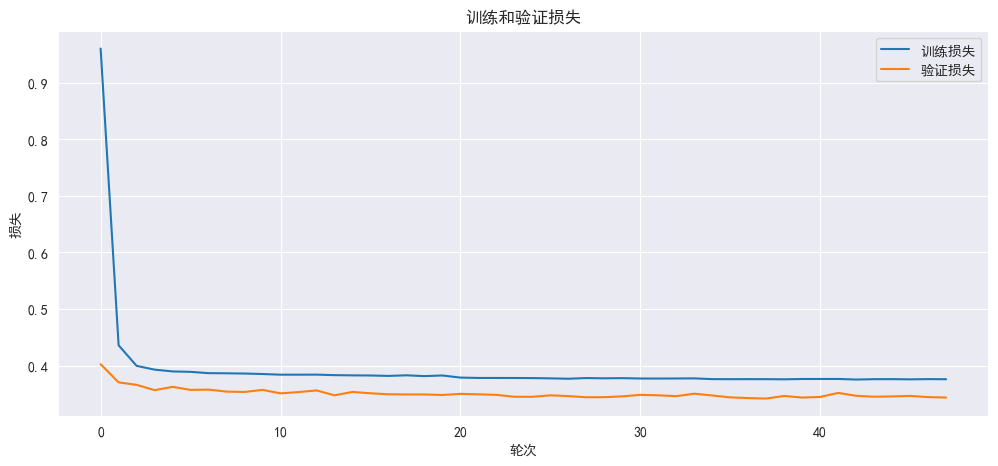

In [27]:
# 绘制训练和验证损失曲线
def plot_loss_curves(train_losses, val_losses, save_path='loss_curves.png'):
    plt.figure(figsize=(12, 5))
    plt.plot(train_losses, label='训练损失')
    plt.plot(val_losses, label='验证损失')
    plt.title('训练和验证损失')
    plt.xlabel('轮次')
    plt.ylabel('损失')
    plt.legend()
    plt.savefig(save_path)
    plt.close()
    logger.info(f"损失曲线已保存到{save_path}")
    
    # 显示图像
    plt.figure(figsize=(12, 5))
    plt.plot(train_losses, label='训练损失')
    plt.plot(val_losses, label='验证损失')
    plt.title('训练和验证损失')
    plt.xlabel('轮次')
    plt.ylabel('损失')
    plt.legend()
    plt.show()

# 绘制损失曲线
plot_loss_curves(train_losses, val_losses, save_path='improved_loss_curves.png')

In [28]:
# 预测函数
def predict(model, test_loader, device):
    logger.info("正在对测试数据进行预测...")
    model.eval()
    predictions = []

    with torch.no_grad():
        for inputs in tqdm(test_loader, desc="测试预测"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            predictions.append(outputs.cpu().numpy())

    # 连接所有批次预测
    predictions = np.concatenate(predictions, axis=0).flatten()
    return predictions

# 进行预测
dl_predictions = predict(model, test_loader, device)

# 预测基线模型结果
baseline_predictions = best_baseline_model.predict(test_baseline_features)

# 反向对数转换
if 'log_price' in train_data.columns:
    dl_predictions = np.expm1(dl_predictions)
    baseline_predictions = np.expm1(baseline_predictions)

# 获取实际价格
actuals = test_labels['price'].values

2025-04-19 23:45:02,308 - price_prediction - INFO - 正在对测试数据进行预测...
测试预测: 100%|██████████| 196/196 [00:00<00:00, 210.69it/s]


In [29]:
# 评估预测
def evaluate_predictions(predictions, actuals, model_name="模型"):
    # 计算指标
    mse = np.mean((predictions - actuals) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predictions - actuals))
    r2 = 1 - np.sum((actuals - predictions) ** 2) / np.sum((actuals - np.mean(actuals)) ** 2)

    # 计算中位数绝对误差(MedAE)
    medae = np.median(np.abs(predictions - actuals))

    # 计算平均绝对百分比误差(MAPE)
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

    logger.info(f"\n{model_name}评估指标:")
    logger.info(f"均方误差 (MSE): {mse:.4f}")
    logger.info(f"均方根误差 (RMSE): {rmse:.4f}")
    logger.info(f"平均绝对误差 (MAE): {mae:.4f}")
    logger.info(f"中位数绝对误差 (MedAE): {medae:.4f}")
    logger.info(f"平均绝对百分比误差 (MAPE): {mape:.4f}%")
    logger.info(f"R²分数: {r2:.4f}")

    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'medae': medae,
        'mape': mape,
        'r2': r2
    }

# 评估深度学习模型
dl_metrics = evaluate_predictions(dl_predictions, actuals, "基于word2vec的价格预测模型")

# 评估基线模型
baseline_metrics = evaluate_predictions(baseline_predictions, actuals, "基线模型")

2025-04-19 23:45:04,176 - price_prediction - INFO - 
基于word2vec的价格预测模型评估指标:
2025-04-19 23:45:04,176 - price_prediction - INFO - 均方误差 (MSE): 1216.9241
2025-04-19 23:45:04,176 - price_prediction - INFO - 均方根误差 (RMSE): 34.8844
2025-04-19 23:45:04,177 - price_prediction - INFO - 平均绝对误差 (MAE): 13.3075
2025-04-19 23:45:04,177 - price_prediction - INFO - 中位数绝对误差 (MedAE): 6.3467
2025-04-19 23:45:04,177 - price_prediction - INFO - 平均绝对百分比误差 (MAPE): 53.1166%
2025-04-19 23:45:04,179 - price_prediction - INFO - R²分数: 0.1642
2025-04-19 23:45:04,180 - price_prediction - INFO - 
基线模型评估指标:
2025-04-19 23:45:04,181 - price_prediction - INFO - 均方误差 (MSE): 1241.9167
2025-04-19 23:45:04,181 - price_prediction - INFO - 均方根误差 (RMSE): 35.2408
2025-04-19 23:45:04,181 - price_prediction - INFO - 平均绝对误差 (MAE): 13.8168
2025-04-19 23:45:04,181 - price_prediction - INFO - 中位数绝对误差 (MedAE): 6.6954
2025-04-19 23:45:04,182 - price_prediction - INFO - 平均绝对百分比误差 (MAPE): 55.7778%
2025-04-19 23:45:04,182 - price_prediction

In [30]:
# 对比两个模型的性能
def compare_models(dl_metrics, baseline_metrics):
    metrics = ['mse', 'rmse', 'mae', 'medae', 'mape', 'r2']
    metric_names = {
        'mse': '均方误差 (MSE)',
        'rmse': '均方根误差 (RMSE)',
        'mae': '平均绝对误差 (MAE)',
        'medae': '中位数绝对误差 (MedAE)',
        'mape': '平均绝对百分比误差 (MAPE) %',
        'r2': 'R²分数'
    }
    
    comparison = pd.DataFrame({
        '基于word2vec的价格预测模型': [dl_metrics[m] for m in metrics],
        '基线模型': [baseline_metrics[m] for m in metrics]
    }, index=[metric_names[m] for m in metrics])
    
    # 计算改进百分比
    comparison['改进百分比'] = [
        ((baseline_metrics[m] - dl_metrics[m]) / baseline_metrics[m]) * 100 
        if m != 'r2' else 
        ((dl_metrics[m] - baseline_metrics[m]) / abs(baseline_metrics[m])) * 100
        for m in metrics
    ]
    
    # 对于R²分数，正值表示改进
    # 对于其他指标，负值表示改进
    
    return comparison

,基于word2vec的价格预测模型,基线模型,改进百分比
均方误差 (MSE),1216.924082,1241.916742,2.012426
均方根误差 (RMSE),34.884439,35.240839,1.011327
平均绝对误差 (MAE),13.307512,13.816802,3.686020
中位数绝对误差 (MedAE),6.346705,6.695391,5.207849
平均绝对百分比误差 (MAPE) %,53.116566,55.777820,4.771169
R²分数,0.164191,0.147026,11.675167


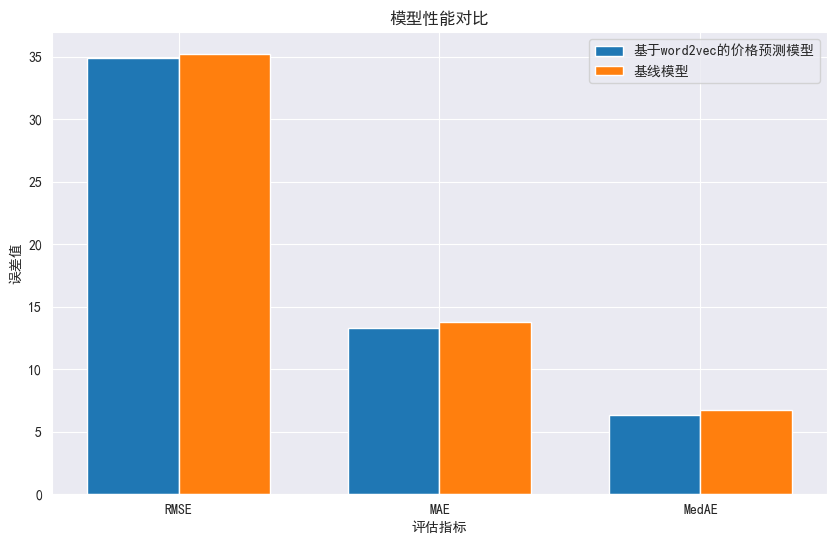

In [31]:
#比较与基线方法的改进
model_comparison = compare_models(dl_metrics, baseline_metrics)
display(model_comparison)

# 绘制比较图表
metrics_to_plot = ['rmse', 'mae', 'medae']
metric_display = {
    'rmse': 'RMSE',
    'mae': 'MAE',
    'medae': 'MedAE'
}

plt.figure(figsize=(10, 6))
x = np.arange(len(metrics_to_plot))
width = 0.35

dl_values = [dl_metrics[m] for m in metrics_to_plot]
baseline_values = [baseline_metrics[m] for m in metrics_to_plot]

plt.bar(x - width/2, dl_values, width, label='基于word2vec的价格预测模型')
plt.bar(x + width/2, baseline_values, width, label='基线模型')

plt.xlabel('评估指标')
plt.ylabel('误差值')
plt.title('模型性能对比')
plt.xticks(x, [metric_display[m] for m in metrics_to_plot])
plt.legend()
plt.show()

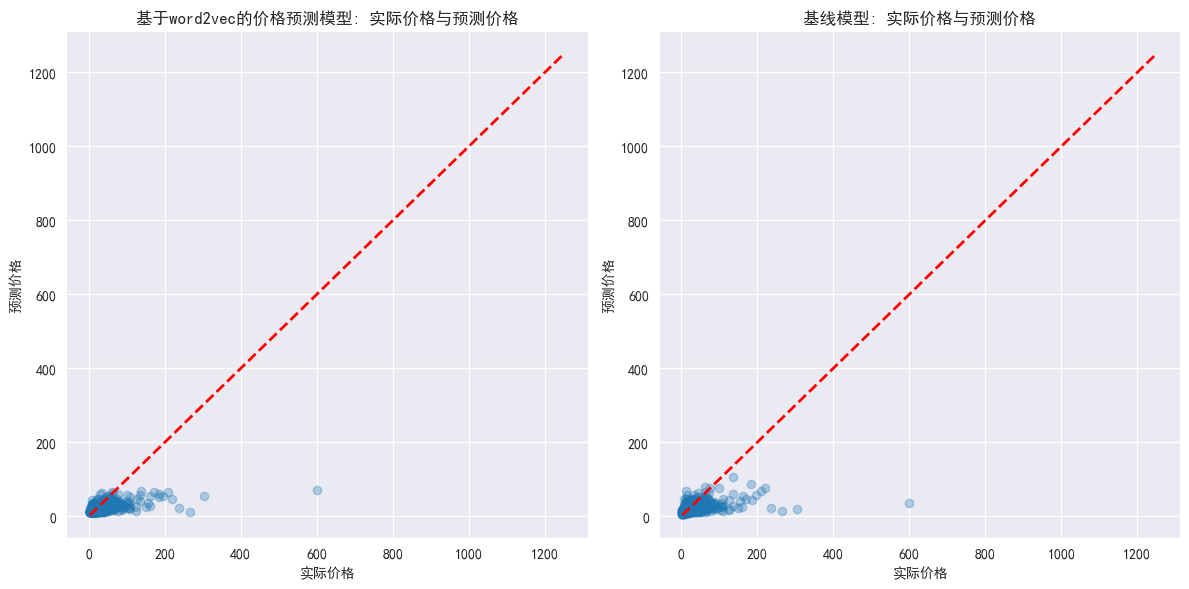

In [32]:
# 绘制预测值与实际值对比散点图
def plot_scatter(actuals, dl_predictions, baseline_predictions, save_path='scatter_plot.png'):
    # 限制样本大小以获得更好的可视化效果
    sample_size = min(1000, len(actuals))
    indices = np.random.choice(len(actuals), sample_size, replace=False)
    
    plt.figure(figsize=(12, 6))
    
    # 创建子图
    plt.subplot(1, 2, 1)
    plt.scatter(actuals[indices], dl_predictions[indices], alpha=0.3)
    plt.plot([min(actuals), max(actuals)], [min(actuals), max(actuals)], 'r--', lw=2)
    plt.xlabel('实际价格')
    plt.ylabel('预测价格')
    plt.title('基于word2vec的价格预测模型: 实际价格与预测价格')
    
    plt.subplot(1, 2, 2)
    plt.scatter(actuals[indices], baseline_predictions[indices], alpha=0.3)
    plt.plot([min(actuals), max(actuals)], [min(actuals), max(actuals)], 'r--', lw=2)
    plt.xlabel('实际价格')
    plt.ylabel('预测价格')
    plt.title('基线模型: 实际价格与预测价格')
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

# 绘制散点图
plot_scatter(actuals, dl_predictions, baseline_predictions, save_path='model_comparison_scatter.png')

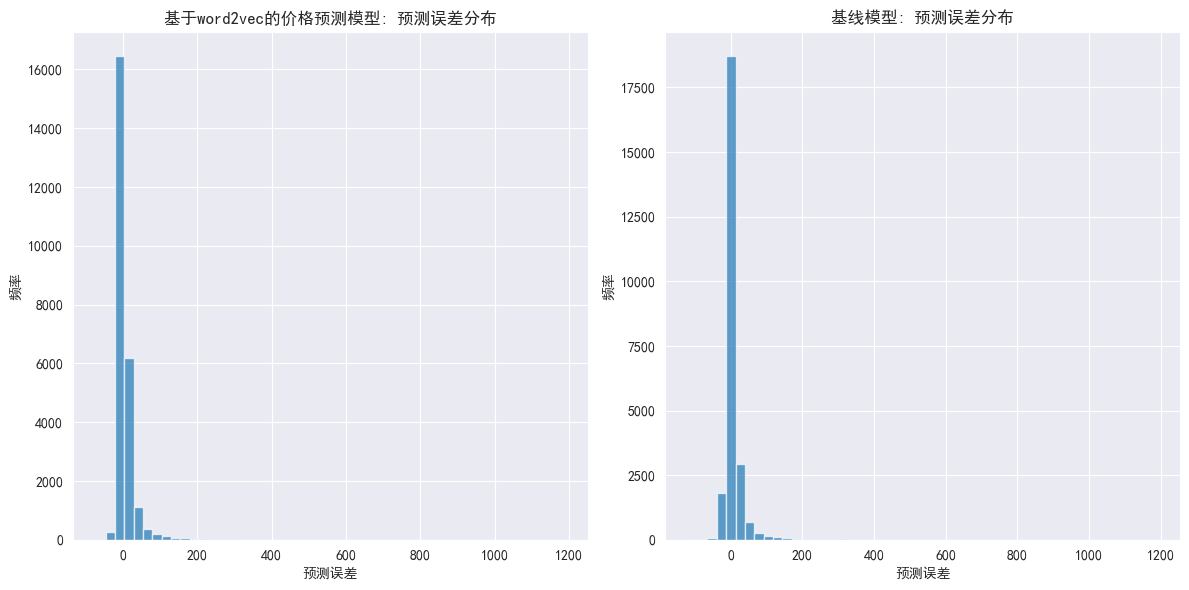

In [33]:
# 绘制误差分布
def plot_error_distributions(actuals, dl_predictions, baseline_predictions, save_path='error_distributions.png'):
    dl_errors = actuals - dl_predictions
    baseline_errors = actuals - baseline_predictions
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.hist(dl_errors, bins=50, alpha=0.7)
    plt.xlabel('预测误差')
    plt.ylabel('频率')
    plt.title('基于word2vec的价格预测模型: 预测误差分布')
    
    plt.subplot(1, 2, 2)
    plt.hist(baseline_errors, bins=50, alpha=0.7)
    plt.xlabel('预测误差')
    plt.ylabel('频率')
    plt.title('基线模型: 预测误差分布')
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

# 绘制误差分布
plot_error_distributions(actuals, dl_predictions, baseline_predictions, save_path='model_error_distributions.png')

In [34]:
#案例研究分析
def perform_case_study(test_data, actuals, predictions, indices=None, num_samples=3):
    if indices is None:
        # 如果未提供索引，则选择随机样本
        indices = np.random.choice(len(test_data), num_samples, replace=False)
    
    case_study_data = test_data.iloc[indices]
    
    # Make sure actuals and predictions are numpy arrays for proper indexing
    actuals = np.array(actuals)
    predictions = np.array(predictions)
    
    case_study_actual = actuals[indices]
    case_study_pred = predictions[indices]
    
    logger.info("\n案例研究分析:")
    for i, (idx, row, actual, pred) in enumerate(
            zip(indices, case_study_data.itertuples(), case_study_actual, case_study_pred)):
        logger.info(f"案例 {i + 1}:")
        logger.info(f"  测试ID: {row.test_id}")
        logger.info(f"  名称: {row.name}")
        logger.info(f"  物品状况ID: {row.item_condition_id}")
        logger.info(f"  类别: {row.category_name}")
        # 品牌名称显示
        brand_display = "未知"
        if hasattr(row, 'original_brand_name') and not pd.isna(row.original_brand_name):
            brand_display = row.original_brand_name
        logger.info(f"  品牌: {brand_display}")
        logger.info(f"  运输: {row.shipping}")
        # 截断长描述
        desc = row.item_description
        logger.info(f"  描述: {desc[:100]}..." if len(desc) > 100 else desc)
        logger.info(f"  实际价格: ${actual:.2f}")
        logger.info(f"  预测价格: ${pred:.2f}")
        logger.info(f"  差异: ${(actual - pred):.2f}")
        logger.info(f"  相对误差: {abs((actual - pred) / actual) * 100:.2f}%")
        logger.info("-" * 50)



In [36]:
#输出三个案例
perform_case_study(test_data, actuals, dl_predictions, num_samples=3)

2025-04-19 23:45:48,916 - price_prediction - INFO - 
案例研究分析:
2025-04-19 23:45:48,920 - price_prediction - INFO - 案例 1:
2025-04-19 23:45:48,920 - price_prediction - INFO -   测试ID: 1635
2025-04-19 23:45:48,921 - price_prediction - INFO -   名称: dale earnhardt 3 men s 2xl t shirt
2025-04-19 23:45:48,924 - price_prediction - INFO -   物品状况ID: 3
2025-04-19 23:45:48,924 - price_prediction - INFO -   类别: men tops t shirts
2025-04-19 23:45:48,924 - price_prediction - INFO -   品牌: NASCAR
2025-04-19 23:45:48,924 - price_prediction - INFO -   运输: 0
2025-04-19 23:45:48,925 - price_prediction - INFO -   描述: This is a used Dale Earnhardt 3 Men s 2 x large vintage Good Wrench T-shirt. Please view the picture...
2025-04-19 23:45:48,925 - price_prediction - INFO -   实际价格: $19.00
2025-04-19 23:45:48,925 - price_prediction - INFO -   预测价格: $18.22
2025-04-19 23:45:48,926 - price_prediction - INFO -   差异: $0.78
2025-04-19 23:45:48,926 - price_prediction - INFO -   相对误差: 4.11%
2025-04-19 23:45:48,927 - price_

In [37]:
# 汇总比较结果
print("模型性能对比总结:")
print("-" * 70)
print(f"基于word2vec的价格预测模型 RMSE: {dl_metrics['rmse']:.4f}")
print(f"基线模型 RMSE: {baseline_metrics['rmse']:.4f}")
improvement = ((baseline_metrics['rmse'] - dl_metrics['rmse']) / baseline_metrics['rmse']) * 100
print(f"RMSE 改进: {improvement:.2f}%")
print("-" * 70)
print(f"基于word2vec的价格预测模型 MAE: {dl_metrics['mae']:.4f}")
print(f"基线模型 MAE: {baseline_metrics['mae']:.4f}")
improvement = ((baseline_metrics['mae'] - dl_metrics['mae']) / baseline_metrics['mae']) * 100
print(f"MAE 改进: {improvement:.2f}%")
print("-" * 70)
print(f"基于word2vec的价格预测模型 R²: {dl_metrics['r2']:.4f}")
print(f"基线模型 R²: {baseline_metrics['r2']:.4f}")
improvement = ((dl_metrics['r2'] - baseline_metrics['r2']) / abs(baseline_metrics['r2'])) * 100
print(f"R² 改进: {improvement:.2f}%")
print("-" * 70)

模型性能对比总结:
----------------------------------------------------------------------
基于word2vec的价格预测模型 RMSE: 34.8844
基线模型 RMSE: 35.2408
RMSE 改进: 1.01%
----------------------------------------------------------------------
基于word2vec的价格预测模型 MAE: 13.3075
基线模型 MAE: 13.8168
MAE 改进: 3.69%
----------------------------------------------------------------------
基于word2vec的价格预测模型 R²: 0.1642
基线模型 R²: 0.1470
R² 改进: 11.68%
----------------------------------------------------------------------
